## Problem Statement

### Business Context

Vehicle breakdowns and engine failures lead to significant financial losses for both individual owners and fleet operators. Unexpected engine failures can cause expensive repairs, operational downtime, and safety risks. Predictive maintenance in the automotive industry can help minimize these issues by leveraging sensor data to forecast potential failures before they occur.

Automobile manufacturers, fleet managers, and service providers aim to develop data-driven solutions to improve engine reliability and optimize maintenance schedules. By analyzing engine health parameters such as RPM, temperature, pressure, and other sensor readings, machine learning models can be trained to predict when an engine requires maintenance, allowing proactive intervention before a failure occurs.

The sensor values in the dataset are consistent with the operating parameters of larger and small engines commonly found in equipment like Vechiles, lawnmowers, portable generators, and compact machinery. Some engines operate at lower RPMs, pressures, and temperatures compared to larger automotive engines and vice versa. Therefore, the data is appropriate for developing predictive maintenance models tailored to large and small engine applications.

### Objective

As a Data Scientist, your goal is to build a predictive maintenance model that can analyze historical and real-time engine sensor data to identify potential failures. The model should accurately classify whether an engine requires maintenance or is operating normally.

This solution will help:

- Reduce unplanned breakdowns and costly repairs.
- Improve vehicle performance and engine lifespan.
- Optimize maintenance schedules to minimize downtime
- Provide data-driven insights to manufacturers and fleet operators for better decision-making.

### Data Dictionary

- `Engine_RPM`: The number of revolutions per minute (RPM) of the engine, indicating engine speed. It is defined in Revolutions per Minute (RPM).
- `Lub_Oil_Pressure`: The pressure of the lubricating oil in the engine, essential for reducing friction and wear. It is defined in bar or kilopascals (kPa)
- `Fuel_Pressure`: The pressure at which fuel is supplied to the engine, critical for proper combustion. It is defined in bar or kilopascals (kPa)
- `Coolant_Pressure`: The pressure of the engine coolant, affecting engine temperature regulation. It is defined in bar or kilopascals (kPa)
- `Lub_Oil_Temperature`: The temperature of the lubricating oil, which impacts viscosity and engine performance. It is defined in degrees Celsius (°C)
- `Coolant_Temperature`: The temperature of the engine coolant, crucial for preventing overheating. It is defined in degrees Celsius (°C)
- `Engine_Condition`: A categorical or numerical label representing the health of the engine, potentially indicating normal operation or various levels of wear and failure risks. It is defined as a - categorical variable (0/1) representing a state such as "0 = Off/False/Active" and "1 = On/True/Faulty"

In [1]:
!pip install xgboost
!pip install joblib
!pip install pandas
!pip install transformers
!pip install torch
#!pip install gradio==4.21.0
!pip install gradio
!pip install huggingface_hub
!pip install sentencepiece
!pip install tokenizers
!pip install streamlit
!pip install scikit-learn==1.4.2 numpy==1.26.4 joblib==1.3.2

## Import the necessary libraries

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats

## Loading the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data/engine_data.csv')

In [5]:
# copying data to another variable to avoid any changes to original data
df = data.copy()

## Data Overview

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

#### Displaying the first few rows of the dataset

In [6]:
# looking at head (5 observations)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


#### Checking the shape of the dataset

In [7]:
df.shape

(19535, 7)

#### Checking the data types of the columns for the dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


- All columns have 19535 non-null values, meaning there are no missing values in the dataset.

- The dataset includes:
  1. Numerical variables: Engine rpm, Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
  2. Categorical variables:

#### Statistical summary of the dataset

In [9]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


- Dataset is well-balanced enough for analysis
- Temperature and pressure metrics are critical indicators
- Extreme values strongly correlate with failures

### Check missing values

In [10]:
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


### Check duplicates

In [11]:
df.duplicated().sum()

0

## Data Registration

In [12]:

from huggingface_hub import HfApi, create_repo
import os
from huggingface_hub.utils import RepositoryNotFoundError

repo_id = "tushar77more/engine_dataset"
repo_type = "dataset"
api = HfApi(token=os.getenv("MLOps"))

# Check if repo exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Dataset '{repo_id}' already exists.")
except RepositoryNotFoundError:
    print(f"Dataset '{repo_id}' not found. Creating...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Dataset '{repo_id}' created.")

Dataset 'tushar77more/engine_dataset' not found. Creating...
Dataset 'tushar77more/engine_dataset' created.


In [13]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/data_register.py"

import os
from huggingface_hub import HfApi

api = HfApi(token=os.getenv("MLOps"))

#folder_path = "data"
folder_path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data"


repo_id = "tushar77more/engine_dataset"

# Optional: see files already on HF
print("Files in HF repo:", api.list_repo_files(repo_id=repo_id, repo_type="dataset"))

api.upload_folder(
    folder_path=folder_path,
    repo_id=repo_id,
    repo_type="dataset",
    commit_message="Initial dataset upload"
)

print(" Dataset files uploaded")

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/data_register.py


### Uploading data to Huggingface

In [14]:
#Uploading data to Huggingface
api = HfApi(token=os.getenv("MLOps"))

#folder_path = "data"
folder_path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data"


repo_id = "tushar77more/engine_dataset"

# Optional: see files already on HF
print("Files in HF repo:", api.list_repo_files(repo_id=repo_id, repo_type="dataset"))

api.upload_folder(
    folder_path=folder_path,
    repo_id=repo_id,
    repo_type="dataset",
    path_in_repo="data",
    commit_message="Initial dataset upload"
)

print(" Dataset files uploaded")

Files in HF repo: ['.gitattributes']
 Dataset files uploaded


### Exploratory Data Analysis

#### Univariate Analysis

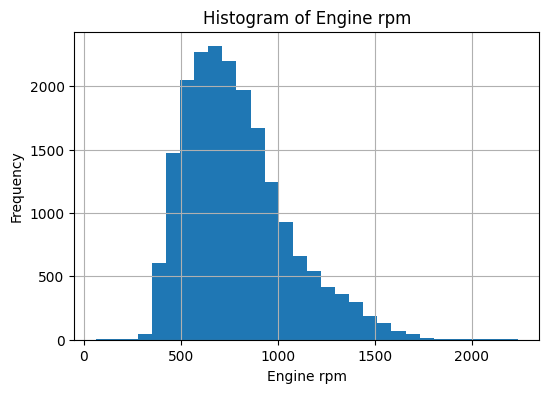

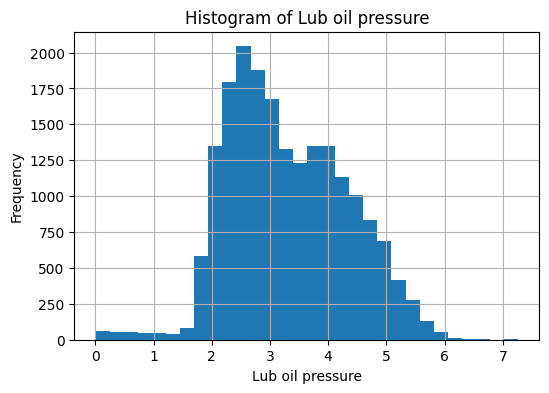

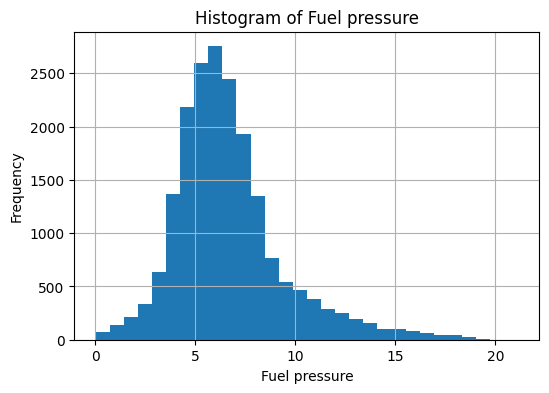

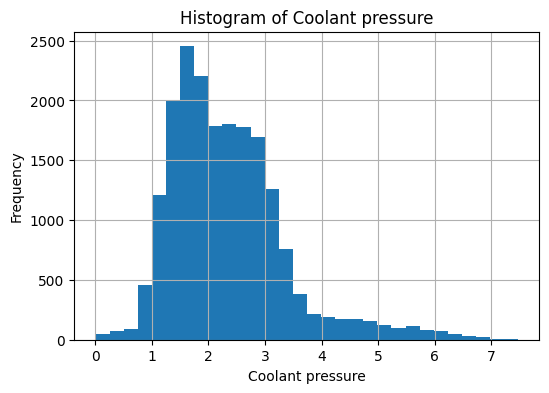

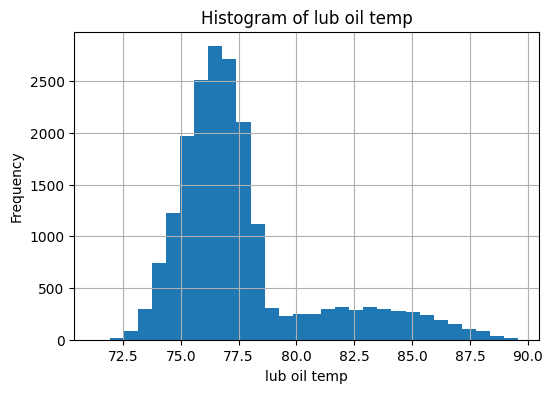

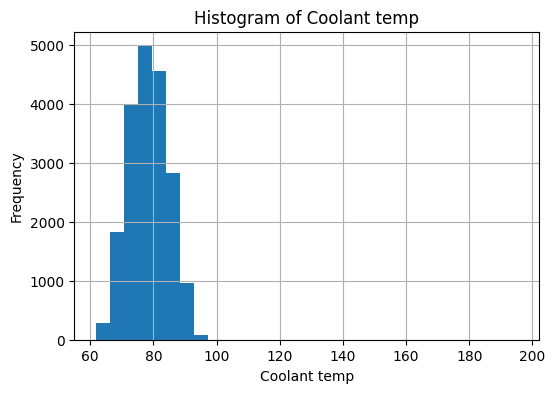

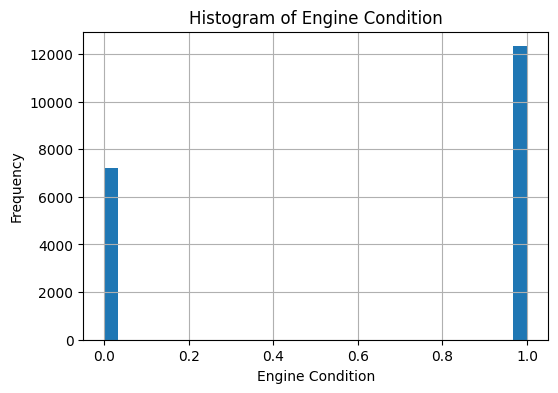

In [15]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


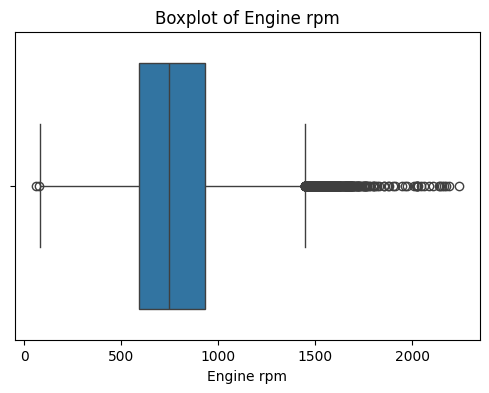

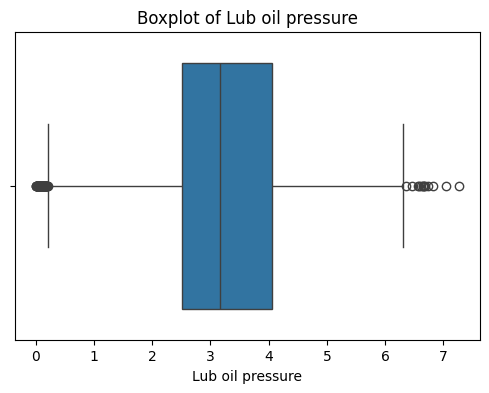

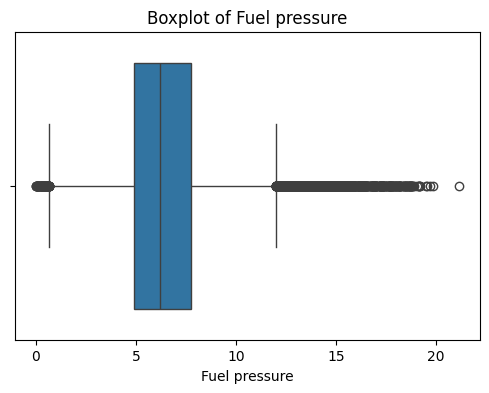

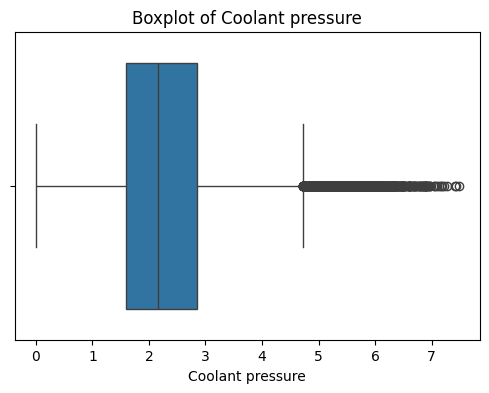

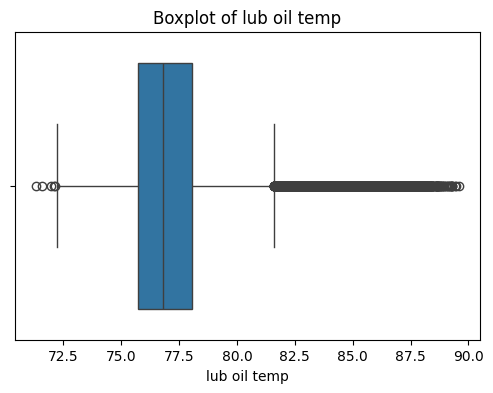

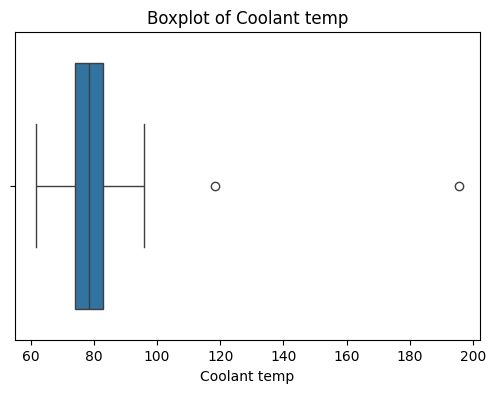

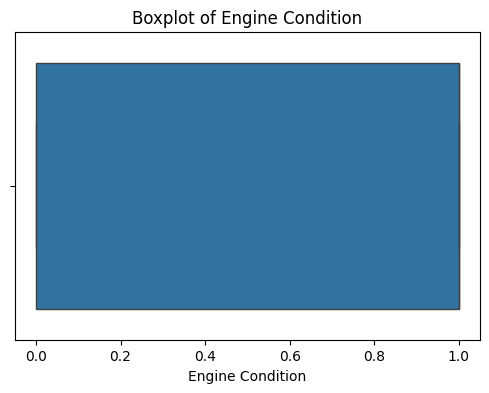

In [16]:

for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


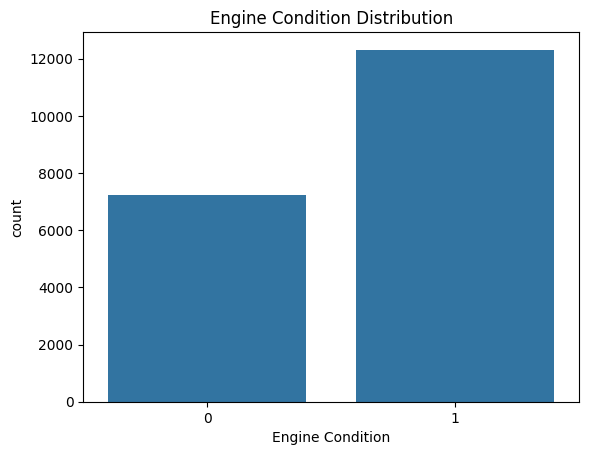

In [17]:
sns.countplot(x='Engine Condition', data=df)
plt.title("Engine Condition Distribution")
plt.show()

###
Bivariate Analysis

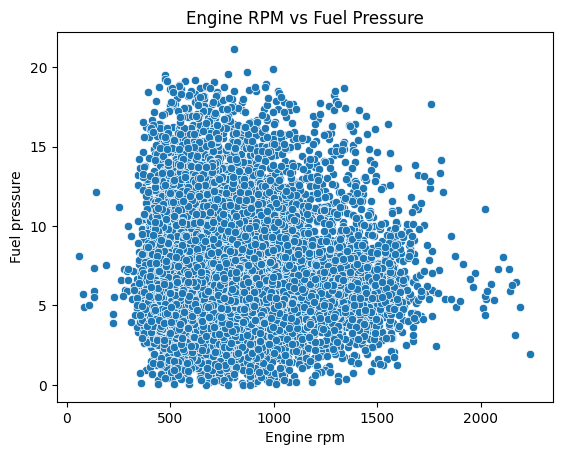

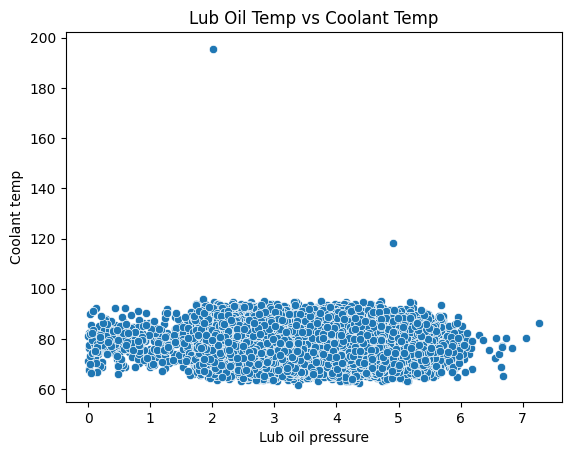

In [18]:
sns.scatterplot(x="Engine rpm", y="Fuel pressure", data=df)
plt.title("Engine RPM vs Fuel Pressure")
plt.show()

sns.scatterplot(x="Lub oil pressure", y="Coolant temp", data=df)
plt.title("Lub Oil Temp vs Coolant Temp")
plt.show()



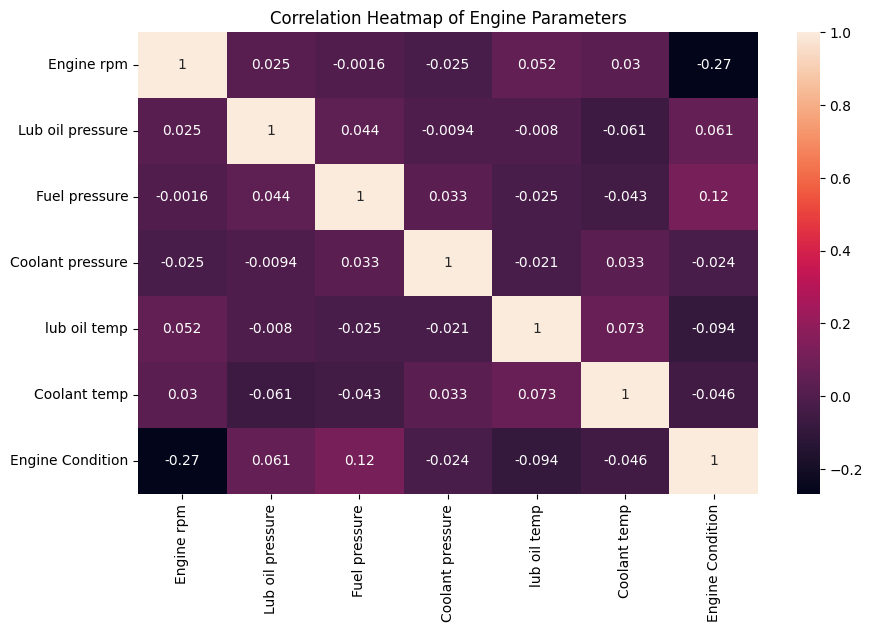

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap of Engine Parameters")
plt.show()


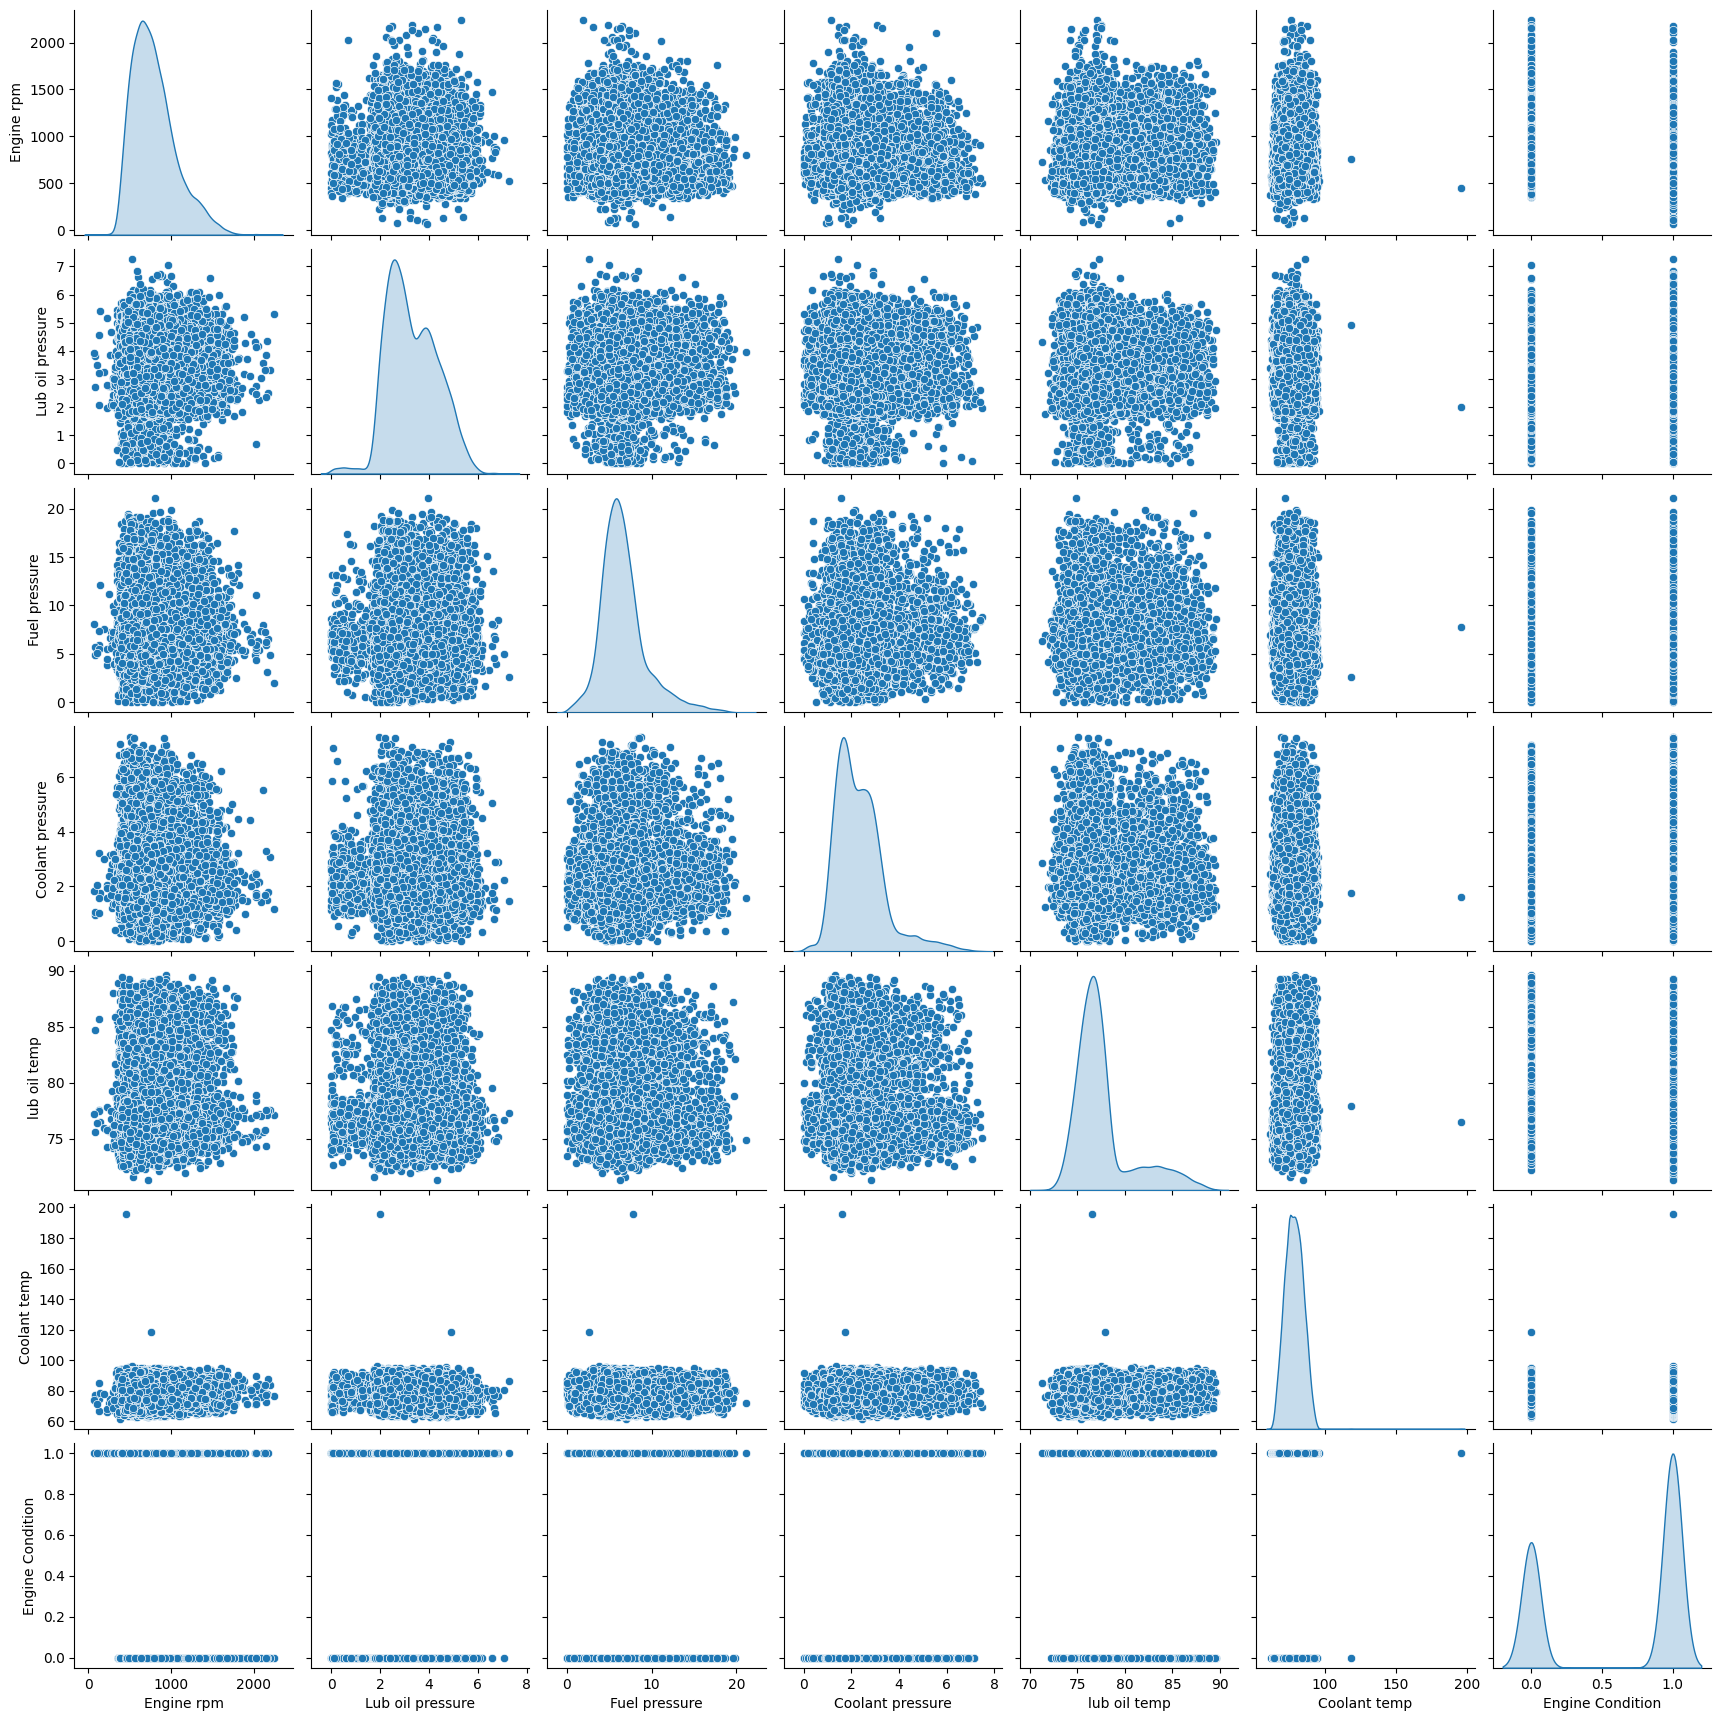

In [20]:
sns.pairplot(df, diag_kind="kde")
plt.show()


#### Insights based on EDA

- The dataset is well-structured and informative
- Temperature and pressure variables are key drivers of engine condition
- Outliers are meaningful and should be retained for modeling
The data is highly suitable for:
  - Classification models
  - Predictive maintenance solutions
  - Fuel pressure and rpm are tightly linked and reliable indicators of load.
  - Temperature variables (coolant, hub oil) are strong predictors of engine condition.
  - abnormal points in pressure vs. rpm or temp vs. pressure relationships highlight potential mechanical issues.

- Engine Condition is primarily affected by rpm, fuel pressure, and temperatures.
- Lub oil pressure and coolant pressure have minimal direct influence but remain critical for anomaly detection.

## Data Preparation

1. **Imports Necessary Libraries**:

2. **Dataset Loading**:
   - The script defines a path to a dataset stored on Hugging Face and reads it into a Pandas DataFrame.

3. **Data Preparation**:
   - The code creates matrices for predictors (features) and the target variable.
   - It splits the dataset into training and testing sets, reserving 20% of the data for testing. This is done to evaluate the model's performance later.

4. **Saving Prepared Data**:
   - After splitting, the script saves the training and testing datasets (features and target) as CSV files.

5. **Uploading Files**:
   - Finally, it uploads these CSV files back to the Hugging Face Hub, ensuring that they are properly stored in the specified repository.

In [21]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/prep.py"

# for data manipulation
import pandas as pd
from datasets import load_dataset
import sklearn
# for creating a folder
import os
# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
# for converting text data in to numerical representation
from sklearn.preprocessing import LabelEncoder
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# Define constants for the dataset and output paths
api = HfApi(token=os.getenv("MLOps"))


dataset = load_dataset(
    "tushar77more/engine_dataset",
    data_files="engine_data.csv",
    split="train"
)

df = dataset.to_pandas()

print("Dataset loaded successfully.")
print("Initial Shape:", df.shape)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop fully empty columns (safety)
df.dropna(axis=1, how='all', inplace=True)

print("Shape after cleaning:", df.shape)

# ---------------------------------
# Define Target Variable
# ---------------------------------
target_col = "Engine Condition"  # Whether customer purchased package

if target_col not in df.columns:
    raise ValueError(" Target column not found!")

# -------------------------------
# Outlier Handling
# -------------------------------
numeric_cols = ["Engine rpm", "Lub oil pressure", "Fuel pressure",
                "Coolant pressure", "lub oil temp", "Coolant temp"]

# Example: Winsorize (cap extreme values at 1st and 99th percentile)
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print("Outliers capped at 1st/99th percentile")

X = df.drop(columns=[target_col])
y = df[target_col]

# ---------------------------------
# Train-Test Split
# ---------------------------------
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Train/Test split done")
print("Xtrain:", Xtrain.shape, "Xtest:", Xtest.shape)

# ---------------------------------
# Save Locally
# ---------------------------------
processed_folder_path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data/processed/"
os.makedirs(processed_folder_path, exist_ok=True)


Xtrain_path = os.path.join(processed_folder_path, "Xtrain.csv")
Xtest_path = os.path.join(processed_folder_path, "Xtest.csv")
ytrain_path = os.path.join(processed_folder_path, "ytrain.csv")
ytest_path = os.path.join(processed_folder_path, "ytest.csv")


Xtrain.to_csv(Xtrain_path, index=False)
Xtest.to_csv(Xtest_path, index=False)
ytrain.to_csv(ytrain_path, index=False)
ytest.to_csv(ytest_path, index=False)

print(" Files saved locally")

# ---------------------------------
# Upload to Hugging Face
# ---------------------------------
files = [Xtrain_path, Xtest_path, ytrain_path, ytest_path]

for file_path in files:
    api.upload_file(
        path_or_fileobj=file_path,
        path_in_repo=f"data/processed/{os.path.basename(file_path)}",
        repo_id="tushar77more/engine_dataset",
        repo_type="dataset",
    )
    print(f" Uploaded: {file_path}")

print(" Preprocessing pipeline completed successfully!")

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/prep.py


### Uploading test and train dataset to Huggingface

In [22]:
import pandas as pd
from datasets import load_dataset
import sklearn
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import HfApi
import numpy as np

# Set your token explicitly
api = HfApi(token=os.getenv("MLOps"))

repo_id = "tushar77more/engine_dataset"
api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)

# Assume df is already loaded from Hugging Face
target_col = "Engine Condition"

if target_col not in df.columns:
    raise ValueError("Target column not found!")

# -------------------------------
# Outlier Handling
# -------------------------------
numeric_cols = ["Engine rpm", "Lub oil pressure", "Fuel pressure",
                "Coolant pressure", "lub oil temp", "Coolant temp"]

# Example: Winsorize (cap extreme values at 1st and 99th percentile)
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print("Outliers capped at 1st/99th percentile")

# -------------------------------
# Train-Test Split
# -------------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test split done")
print("Xtrain:", Xtrain.shape, "Xtest:", Xtest.shape)

# -------------------------------
# Save Locally
# -------------------------------
processed_folder_path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data/processed"
os.makedirs(processed_folder_path, exist_ok=True)

Xtrain.to_csv(os.path.join(processed_folder_path, "Xtrain.csv"), index=False)
Xtest.to_csv(os.path.join(processed_folder_path, "Xtest.csv"), index=False)
ytrain.to_csv(os.path.join(processed_folder_path, "ytrain.csv"), index=False)
ytest.to_csv(os.path.join(processed_folder_path, "ytest.csv"), index=False)

print("Files saved locally")

# -------------------------------
# Upload to Hugging Face
# -------------------------------
api.upload_folder(
    folder_path=processed_folder_path,
    repo_id=repo_id,
    repo_type="dataset",
    commit_message="Added processed train/test splits with outlier handling",
    path_in_repo="data/processed"
)


Outliers capped at 1st/99th percentile
Train/Test split done
Xtrain: (15628, 6) Xtest: (3907, 6)
Files saved locally


No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/tushar77more/engine_dataset/commit/de70e1e83d52de64ba004e09510023723b3cb3a1', commit_message='Added processed train/test splits with outlier handling', commit_description='', oid='de70e1e83d52de64ba004e09510023723b3cb3a1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/tushar77more/engine_dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='tushar77more/engine_dataset'), pr_revision=None, pr_num=None)

## Model Building with Experimentation Tracking

#### Load Train/Test Data from Hugging Face

In [23]:
import pandas as pd
from datasets import load_dataset


# Assuming you already have Xtrain, Xtest, ytrain, ytest
train_df = pd.concat([Xtrain, ytrain], axis=1)
test_df  = pd.concat([Xtest, ytest], axis=1)

train_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data/processed/train.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/data/processed/test.csv", index=False)

api.upload_folder(
    folder_path=processed_folder_path,
    repo_id="tushar77more/engine_dataset",
    repo_type="dataset",
    commit_message="Added merged train/test splits",
    path_in_repo="data/processed"
)

dataset = load_dataset(
    "tushar77more/engine_dataset",
    data_files={
        "train": "data/processed/train.csv",
        "test": "data/processed/test.csv"
    }
)

train_df = dataset["train"].to_pandas()
test_df  = dataset["test"].to_pandas()

Xtrain = train_df.drop(columns=["Engine Condition"])
ytrain = train_df["Engine Condition"]

Xtest = test_df.drop(columns=["Engine Condition"])
ytest = test_df["Engine Condition"]


No files have been modified since last commit. Skipping to prevent empty commit.


train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

#### Define Candidate Models and Parameters

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb

models = {
    "DecisionTree": (DecisionTreeClassifier(), {"max_depth":[3,5,10]}),
    "Bagging": (BaggingClassifier(), {"n_estimators":[50,100]}),
    "RandomForest": (RandomForestClassifier(), {"n_estimators":[100,200], "max_depth":[5,10]}),
    "AdaBoost": (AdaBoostClassifier(), {"n_estimators":[50,100]}),
    "GradientBoosting": (GradientBoostingClassifier(), {"n_estimators":[100,200], "learning_rate":[0.05,0.1]}),
    "XGBoost": (xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"), {"n_estimators":[100,200], "max_depth":[3,5]})
}


#### Tune Models with GridSearchCV

In [25]:
from sklearn.model_selection import GridSearchCV

best_models = {}
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(Xtrain, ytrain)
    best_models[name] = grid
    print(f"{name} best params: {grid.best_params_}")


DecisionTree best params: {'max_depth': 5}
Bagging best params: {'n_estimators': 100}
RandomForest best params: {'max_depth': 10, 'n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost best params: {'n_estimators': 100}
GradientBoosting best params: {'learning_rate': 0.05, 'n_estimators': 200}
XGBoost best params: {'max_depth': 3, 'n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:10:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Log Tuned Parameters

In [26]:
import json

with open("tuned_params.json", "w") as f:
    json.dump({name:grid.best_params_ for name,grid in best_models.items()}, f, indent=4)

#### Evaluate Model Performance

In [27]:
from sklearn.metrics import accuracy_score, classification_report

results = {}
for name, grid in best_models.items():
    ypred = grid.predict(Xtest)
    acc = accuracy_score(ytest, ypred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(ytest, ypred))

best_model_name = max(results, key=results.get)
best_model = best_models[best_model_name].best_estimator_

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]:.4f}")

DecisionTree Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.56      0.36      0.44      1444
           1       0.69      0.84      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.64      0.66      0.64      3907

Bagging Accuracy: 0.6432
              precision    recall  f1-score   support

           0       0.52      0.39      0.45      1444
           1       0.69      0.79      0.74      2463

    accuracy                           0.64      3907
   macro avg       0.61      0.59      0.59      3907
weighted avg       0.63      0.64      0.63      3907

RandomForest Accuracy: 0.6621
              precision    recall  f1-score   support

           0       0.57      0.35      0.43      1444
           1       0.69      0.85      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60

#### Register Best Model on Hugging Face Hub

In [28]:
from huggingface_hub import HfApi, create_repo
import joblib
import os

# Save best model locally
model_path = f"{best_model_name}_best_model.pkl"
joblib.dump(best_model, model_path)

# Create model repo if not exists
MODEL_REPO_ID = "tushar77more/engine_model"
HF_TOKEN = os.getenv("MLOps")

create_repo(
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    exist_ok=True,
    token=HF_TOKEN
)

# Upload model file
api = HfApi(token=HF_TOKEN)
api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=f"{best_model_name}_best_model.pkl",
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    commit_message=f"Registered best {best_model_name} model"
)




Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ntBoosting_best_model.pkl: 100%|##########|  373kB /  373kB            

CommitInfo(commit_url='https://huggingface.co/tushar77more/engine_model/commit/b0be03a47f067d70649f18672a7e76d2cf0af123', commit_message='Registered best GradientBoosting model', commit_description='', oid='b0be03a47f067d70649f18672a7e76d2cf0af123', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tushar77more/engine_model', endpoint='https://huggingface.co', repo_type='model', repo_id='tushar77more/engine_model'), pr_revision=None, pr_num=None)

## Requirements file for the Github Actions Workflow

In [56]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/requirements.txt"
setuptools>=65.0.0
wheel
huggingface_hub==0.23.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.4.2
xgboost==1.7.6
joblib==1.3.2




Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/requirements.txt


# Deployment

In [30]:
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment", exist_ok=True)

In [31]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/Dockerfile"
FROM python:3.10-slim

WORKDIR /app

COPY . /app

RUN pip install --no-cache-dir \
    fastapi \
    uvicorn \
    pandas==1.5.3 \
    numpy==1.24.3 \
    scikit-learn==1.2.2 \
    xgboost==1.7.6 \
    joblib==1.3.2

EXPOSE 7860

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "7860"]

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/Dockerfile


### Load the saved model from the Hugging Face model hub

In [32]:
from huggingface_hub import hf_hub_download
import joblib

path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment"

MODEL_REPO = "tushar77more/engine_model"
MODEL_FILE = "GradientBoosting_best_model.pkl"

model_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename=MODEL_FILE
)

model = joblib.load(model_path)
model_path = path + "/GradientBoosting_best_model.pkl"

joblib.dump(best_model, model_path)

print("Saved at:", model_path)

GradientBoosting_best_model.pkl:   0%|          | 0.00/373k [00:00<?, ?B/s]

Saved at: /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/GradientBoosting_best_model.pkl


### Get the inputs and save them into a dataframe

In [33]:
import pandas as pd

def prepare_input(data):
    df = pd.DataFrame([data])
    return df

In [34]:
sample_input = {
    "Engine_RPM": 1500,
    "Lub_Oil_Pressure": 3.5,
    "Fuel_Pressure": 5.2,
    "Coolant_Pressure": 2.1,
    "Lub_Oil_Temp": 80,
    "Coolant_Temp": 95
}

In [35]:
def predict(data):
    df = prepare_input(data)
    prediction = model.predict(df)[0]
    return "Faulty Engine" if prediction == 1 else "Normal Engine"

### app.py

In [46]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/app.py"

import streamlit as st
import pandas as pd
import joblib
import os

# -------------------------------
#  Page Config
# -------------------------------
st.set_page_config(page_title="Engine Maintenance Predictor", layout="wide")
st.title("Engine Predictive Maintenance")

# -------------------------------
#  Load Model
# -------------------------------
@st.cache_resource
def load_model():
    model_filename = "GradientBoosting_best_model.pkl"

    if os.path.exists(model_filename):
        try:
            return joblib.load(model_filename)
        except Exception as e:
            st.error(f" Error loading model: {e}")
            return None
    else:
        st.error(f" Model file '{model_filename}' not found!")
        st.info(f"Available files: {os.listdir('.')}")
        return None

model = load_model()

# -------------------------------
#  Input UI
# -------------------------------
st.header("Enter Engine Sensor Details")

col1, col2, col3 = st.columns(3)

with col1:
    Engine_RPM = st.number_input("Engine RPM", 500, 5000, 1500)

with col2:
    Lub_Oil_Pressure = st.number_input("Lub Oil Pressure", 0.0, 10.0, 3.5)

with col3:
    Fuel_Pressure = st.number_input("Fuel Pressure", 0.0, 10.0, 5.2)

col4, col5, col6 = st.columns(3)

with col4:
    Coolant_Pressure = st.number_input("Coolant Pressure", 0.0, 10.0, 2.1)

with col5:
    Lub_Oil_Temp = st.number_input("Lub Oil Temp (°C)", 0, 150, 80)

with col6:
    Coolant_Temp = st.number_input("Coolant Temp (°C)", 0, 150, 95)

# -------------------------------
#  Prediction
# -------------------------------
if st.button("Predict Engine Condition"):

    if model:
        data = {
            "Engine_RPM": Engine_RPM,
            "Lub_Oil_Pressure": Lub_Oil_Pressure,
            "Fuel_Pressure": Fuel_Pressure,
            "Coolant_Pressure": Coolant_Pressure,
            "Lub_Oil_Temp": Lub_Oil_Temp,
            "Coolant_Temp": Coolant_Temp
        }

        input_df = pd.DataFrame([data])

        try:
            # Ensure correct feature order (VERY IMPORTANT)
            if hasattr(model, "feature_names_in_"):
                input_df = input_df[list(model.feature_names_in_)]

            prediction = model.predict(input_df)[0]

            st.divider()

            if prediction == 1:
                st.error("Engine is likely FAULTY!")
                st.warning("Immediate maintenance recommended.")
            else:
                st.success("Engine is operating normally.")

        except Exception as e:
            st.error(f"Prediction Error: {e}")

    else:
        st.error("Model not loaded properly.")

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/app.py


### Hugging Face Deployment Script

In [57]:
from huggingface_hub import HfApi, create_repo
import os

HF_TOKEN = os.getenv("MLOps")
SPACE_ID = "tushar77more/engine-maintenance-app"

# Create space
create_repo(
    repo_id=SPACE_ID,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True,
    token=HF_TOKEN
)

api = HfApi(token=HF_TOKEN)

# Upload files
#files = ["app.py", "requirements.txt", "Dockerfile"]
files = [
    "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/app.py",
    "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/requirements.txt",
    "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/Dockerfile",
    "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/deployment/GradientBoosting_best_model.pkl"
]

for file in files:
    api.upload_file(
        path_or_fileobj=file,
        #path_in_repo=file,
        path_in_repo=os.path.basename(file),
        repo_id=SPACE_ID,
        repo_type="space"
    )

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ntBoosting_best_model.pkl: 100%|##########|  373kB /  373kB            

No files have been modified since last commit. Skipping to prevent empty commit.


### Create a pipeline.yml file in the GitHub repo


```
name: Engine Predictive Maintenance Pipeline

on:
  push:
    branches:
      - main
  workflow_dispatch:

jobs:
  ml-pipeline:
    runs-on: ubuntu-latest

    steps:

    # -------------------------------
    # 1. Checkout Code
    # -------------------------------
    - name: Checkout repository
      uses: actions/checkout@v3

    # -------------------------------
    # 2. Setup Python
    # -------------------------------
    - name: Setup Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.10'

    # -------------------------------
    # 3. Install Dependencies
    # -------------------------------
    - name: Install dependencies
      run: |
        pip install --upgrade pip
        pip install pandas numpy scikit-learn xgboost joblib

    # -------------------------------
    # 4. Data Registration
    # -------------------------------
    - name: Load & Register Data
      run: |
        python src/model_building/data_register.py

    # -------------------------------
    # 5. Data Preprocessing
    # -------------------------------
    - name: Data Preprocessing
      run: |
        python src/model_building/prep.py

    # -------------------------------
    # 6. Train Model
    # -------------------------------
    - name: Train Model
      run: |
        python src/model_building/train.py

    # -------------------------------
    # 7. Evaluate Model
    # -------------------------------
    - name: Evaluate Model
      run: |
        python src/model_building/evaluate.py

    # -------------------------------
    # 8. Save Model to Deployment Folder
    # -------------------------------
    - name: Save Model
      run: |
        mkdir -p src/deployment
        cp model/best_model.pkl src/deployment/GradientBoosting_best_model.pkl

    # -------------------------------
    # 9. Upload Model Artifact
    # -------------------------------
    - name: Upload Model Artifact
      uses: actions/upload-artifact@v3
      with:
        name: trained-model
        path: src/deployment/GradientBoosting_best_model.pkl

    # -------------------------------
    # 10. (Optional) Push Model to Hugging Face
    # -------------------------------
    - name: Push model to Hugging Face
      if: success()
      env:
        HF_TOKEN: ${{ secrets.HF_TOKEN }}
      run: |
        pip install huggingface_hub
        python -

from huggingface_hub import HfApi
api = HfApi(token="${HF_TOKEN}")

api.upload_file(
    path_or_fileobj="src/deployment/GradientBoosting_best_model.pkl",
    path_in_repo="GradientBoosting_best_model.pkl",
    repo_id="tushar77more/engine_model",
    repo_type="model"
)

```

In [48]:
import os

# Define the path
path = "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building"

# Create the directory if it doesn't exist
os.makedirs(path, exist_ok=True)


In [49]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/train.py"

import pandas as pd
import joblib
from sklearn.ensemble import GradientBoostingClassifier

Xtrain = pd.read_csv("/data/processed/Xtrain.csv")
ytrain = pd.read_csv("/data/processed/ytrain.csv").values.ravel()

model = GradientBoostingClassifier()
model.fit(Xtrain, ytrain)

joblib.dump(model, "model/GradientBoosting_best_model.pkl")

print("Model trained & saved")

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/train.py


In [50]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/evaluate.py"
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score

Xtest = pd.read_csv("/data/processed/Xtest.csv")
ytest = pd.read_csv("/data/processed/ytest.csv").values.ravel()

model = joblib.load("model/GradientBoosting_best_model.pkl")

pred = model.predict(Xtest)

print("Accuracy:", accuracy_score(ytest, pred))

Overwriting /content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/model_building/evaluate.py


In [ ]:
!git pull origin main --rebase
!git push origin main


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


## Github Authentication and Push Files

In [58]:
import os

# Install Git
!apt-get install git -y

# Set Git identity
!git config --global user.email "tushar77more@gmail.com"
!git config --global user.name "tushar77more"

# Go to content directory
%cd /content

# Remove any old clone to avoid "already exists" errors
!rm -rf engine_predictive_maintenance

# Clone fresh repo
!git clone https://github.com/tushar77more/engine_predictive_maintenance.git

# Move project files from Drive into repo folder
!cp -r "/content/drive/MyDrive/Colab Notebooks/Predictive_Maintenance_Interim_Report/." /content/engine_predictive_maintenance/


# Now ENTER repo (this persists)
%cd /content/engine_predictive_maintenance

#TOKEN = os.getenv("GITHUB_TOKEN")

GITHUB_TOKEN=os.getenv("GITHUB_TOKEN")


# Add files
!git add .

# Commit
!git commit -m "Added Engine Predictive Maintenance project"

# Set remote with token
!git remote set-url origin https://$GITHUB_TOKEN@github.com/tushar77more/engine_predictive_maintenance.git

# Push
!git push origin main


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
/content
Cloning into 'engine_predictive_maintenance'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 30 (delta 4), reused 25 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 2.43 MiB | 9.17 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/engine_predictive_maintenance
[main 148360c] Added Engine Predictive Maintenance project
 6 files changed, 108 insertions(+), 39 deletions(-)
 rewrite Predictive_Maintenance_final_Report.ipynb (73%)
 rewrite deployment/GradientBoosting_best_model.pkl (94%)
 rewrite deployment/app.py (91%)
fatal: could not read Password for 'https://None@github.com': No such device or address


## Output Evaluation

### GitHub (link to repository, screenshot of folder structure and executed workflow)

- Repository Link
      - https://github.com/tushar77more/engine_predictive_maintenance/tree/main

- Folder Structure

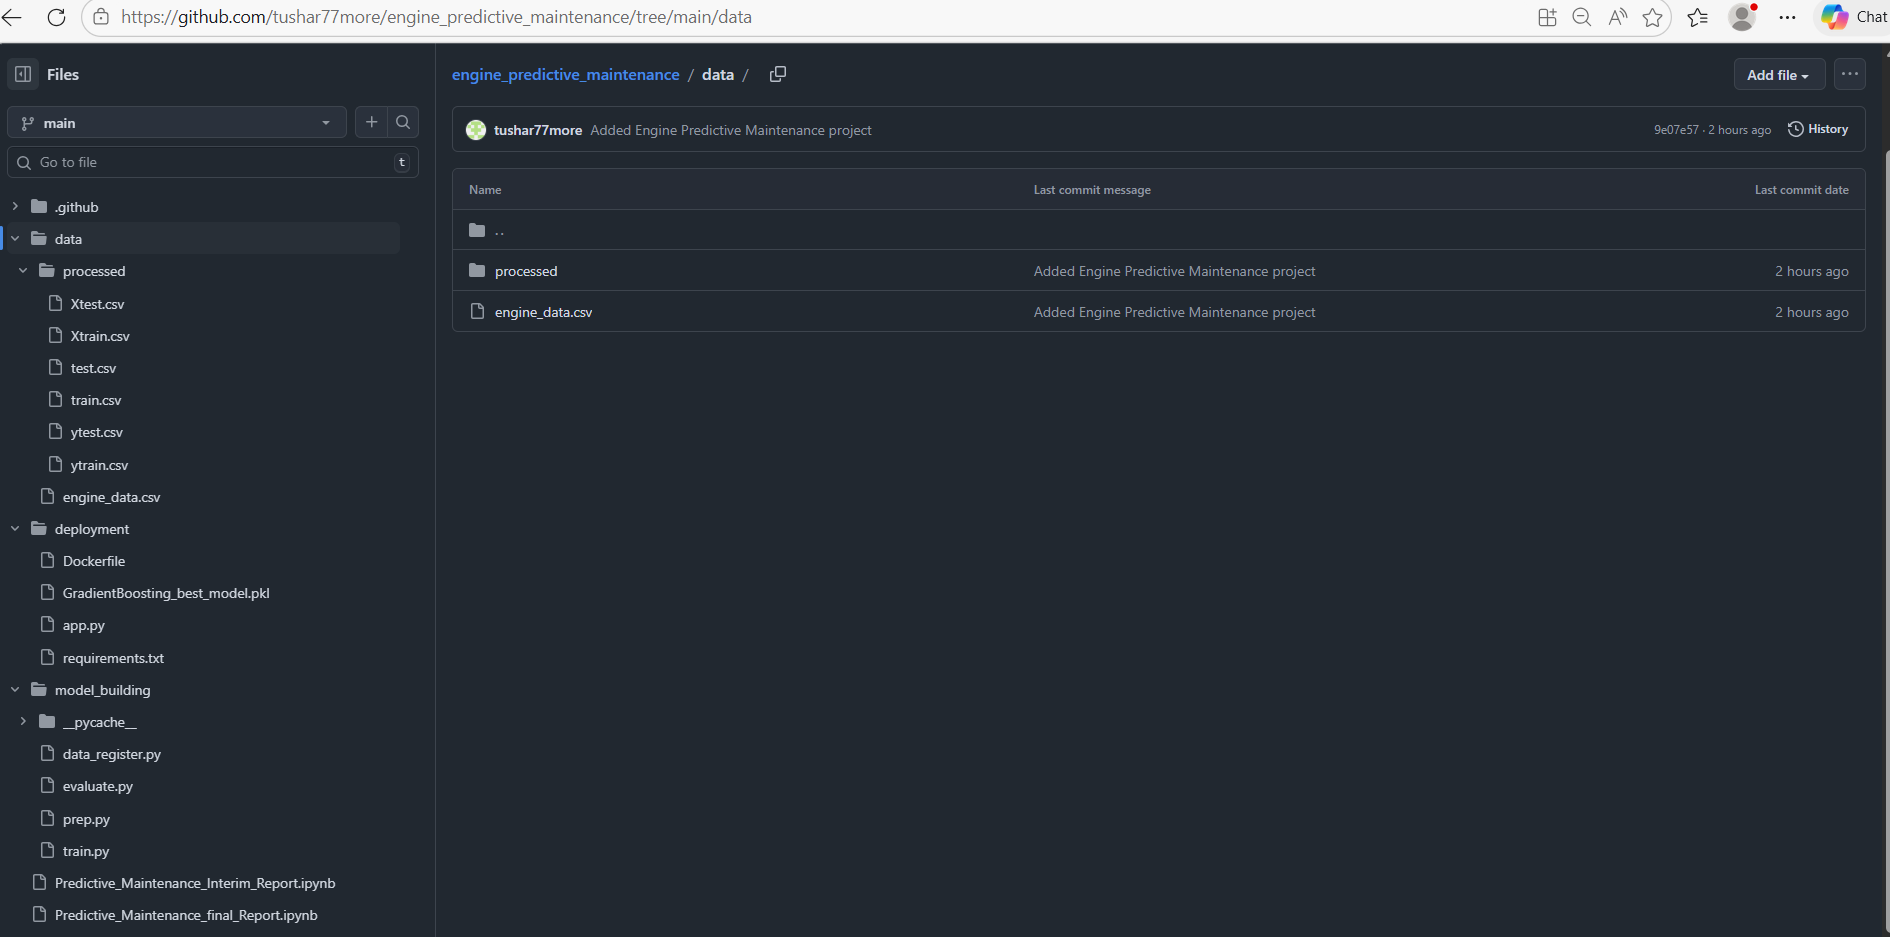

 ```
 /
 ├── data/
 │    ├── engine_data.csv
 │    └── processed/
 │         ├── Xtrain.csv
 │         ├── Xtest.csv
 │         ├── ytrain.csv
 │         ├── ytest.csv
 │
 ├── model_building/
 │    ├── data_register.py
 │    ├── prep.py
 │    ├── train.py
 │    ├── evaluate.py
 │
 ├── deployment/
 │    ├── app.py
 │    ├── dockerfile
 │    ├── GradientBoosting_best_model.pkl
 │    ├── requirement.txt
 │
 ├── hosting/
 │
.github/
 └── workflows/
      └── pipeline.yml
```

In [44]:
import requests

url = "https://tushar77more-engine-maintenance-app.hf.space/predic"

data = {
    "Engine_RPM": 1500,
    "Lub_Oil_Pressure": 3.5,
    "Fuel_Pressure": 5.2,
    "Coolant_Pressure": 2.1,
    "Lub_Oil_Temp": 80,
    "Coolant_Temp": 95
}

response = requests.post(url, json=data)

print(response.json())

JSONDecodeError: Expecting value: line 1 column 1 (char 0)